# Exploratory Data Analysis

Understanding the structure of the airline fare dataset to motivate the Graph Neural Network approach. Key questions: how is fare distributed? what does the route graph look like? are there seasonal and geographic patterns?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datashader as ds
import datashader.transfer_functions as tf

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# RdBu_r accent color for single-color plots
BLUE = '#4393c3'
RED  = '#d6604d'
# Quarter color key (RdBu_r-inspired: Q1=dark blue → Q4=dark red)
Q_COLORS = {'1': '#2166ac', '2': '#74add1', '3': '#f46d43', '4': '#d73027'}

In [2]:
DATA_PATH = '../../data/clean_data/T_DB1B_MARKET_CLEAN.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Full dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

# 10% sample for visualizations — full dataset used for aggregate stats
df_sample = df.sample(frac=0.1, random_state=42).reset_index(drop=True)
print(f"\nSample for plots: {df_sample.shape[0]:,} rows")
df_sample.head()

Full dataset: 26,454,424 rows × 19 columns
Columns: ['YEAR', 'QUARTER', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'DEST_AIRPORT_ID', 'DEST', 'REPORTING_CARRIER', 'TICKET_CARRIER', 'OPERATING_CARRIER', 'BULK_FARE', 'PASSENGERS', 'MARKET_FARE', 'MARKET_DISTANCE', 'NONSTOP_MILES', 'MKT_GEO_TYPE', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON']

Sample for plots: 2,645,442 rows


,YEAR,QUARTER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,REPORTING_CARRIER,TICKET_CARRIER,OPERATING_CARRIER,BULK_FARE,PASSENGERS,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,MKT_GEO_TYPE,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON
0,2025,1,12953,LGA,13303,MIA,AA,AA,AA,0.0,1.0,110.0,1096.0,1096.0,2,40.777199,-73.872597,25.793200,-80.290604
1,2024,3,11618,EWR,15024,STT,AA,AA,AA,0.0,1.0,321.0,2192.0,1634.0,1,40.692501,-74.168701,18.337299,-64.973396
2,2025,2,12266,IAH,12264,IAD,DL,DL,DL,0.0,1.0,224.0,1223.0,1190.0,2,29.984400,-95.341400,38.944500,-77.455803
3,2024,4,11697,FLL,14100,PHL,AA,AA,AA,0.0,16.0,266.0,992.0,992.0,2,26.072599,-80.152702,39.871899,-75.241096
4,2024,4,10721,BOS,12451,JAX,AA,AA,AA,0.0,1.0,175.0,1056.0,1010.0,2,42.364300,-71.005203,30.494101,-81.687897


## 2. Target Variable — MARKET_FARE

In [3]:
df_sample.describe()

,YEAR,QUARTER,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,BULK_FARE,PASSENGERS,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,MKT_GEO_TYPE,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON
count,2.645442e+06,2.645442e+06,2.645442e+06,2.645442e+06,2645442.0,2.645442e+06,2.645442e+06,2.645442e+06,2.645442e+06,2.645442e+06,2.645442e+06,2.645442e+06,2.645442e+06,2.645442e+06
mean,2.024484e+03,2.557419e+00,1.280515e+04,1.280592e+04,0.0,1.705555e+00,3.096143e+02,1.190162e+03,1.119474e+03,1.947097e+00,3.662002e+01,-9.460438e+01,3.665308e+01,-9.457695e+01
std,4.997382e-01,1.106143e+00,1.545655e+03,1.546146e+03,0.0,3.160815e+00,2.260967e+02,7.433803e+02,7.068606e+02,2.238408e-01,6.163583e+00,1.851989e+01,6.153245e+00,1.848009e+01
min,2.024000e+03,1.000000e+00,1.013500e+04,1.013500e+04,0.0,1.000000e+00,1.908000e+01,3.100000e+01,3.100000e+01,1.000000e+00,-1.433100e+01,-1.766460e+02,-1.433100e+01,-1.766460e+02
25%,2.024000e+03,2.000000e+00,1.129200e+04,1.129200e+04,0.0,1.000000e+00,1.835000e+02,6.510000e+02,6.100000e+02,2.000000e+00,3.289680e+01,-1.111530e+02,3.289680e+01,-1.111530e+02
50%,2.024000e+03,3.000000e+00,1.289200e+04,1.289600e+04,0.0,1.000000e+00,2.620000e+02,1.013000e+03,9.510000e+02,2.000000e+00,3.736260e+01,-8.790480e+01,3.736260e+01,-8.790480e+01
75%,2.025000e+03,4.000000e+00,1.410700e+04,1.410700e+04,0.0,1.000000e+00,3.690000e+02,1.575000e+03,1.482000e+03,2.000000e+00,4.077720e+01,-8.094310e+01,4.077720e+01,-8.094310e+01
max,2.025000e+03,4.000000e+00,1.642200e+04,1.642200e+04,0.0,4.100000e+02,3.873500e+04,9.712000e+03,9.362000e+03,2.000000e+00,7.128540e+01,1.457290e+02,7.128540e+01,1.457290e+02


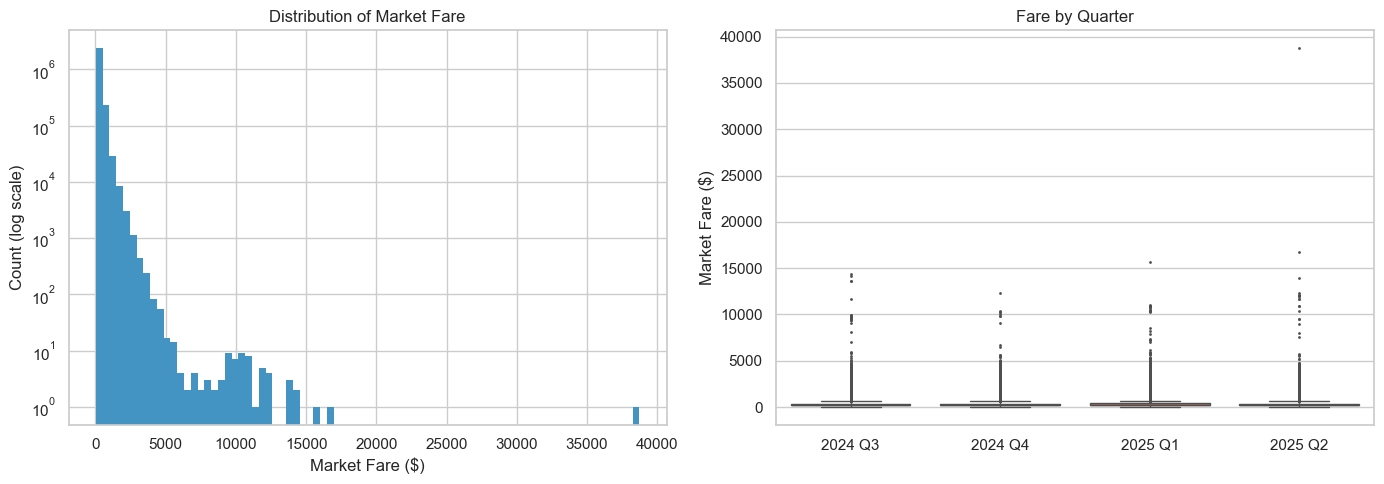

Fare statistics:
count    2.645442e+07
mean     3.095156e+02
std      2.247697e+02
min      1.901000e+01
50%      2.620000e+02
75%      3.690000e+02
95%      6.578700e+02
99%      1.169025e+03
max      4.443200e+04

Fares above $1,000: 1.5%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution — log y scale
axes[0].hist(df_sample['MARKET_FARE'], bins=80, color=BLUE, edgecolor='none', log=True)
axes[0].set_xlabel('Market Fare ($)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Distribution of Market Fare')

# Box plot by quarter — seaborn supports `order`
df_sample['Quarter'] = df_sample['YEAR'].astype(str) + ' Q' + df_sample['QUARTER'].astype(str)
order = sorted(df_sample['Quarter'].unique())
sns.boxplot(data=df_sample, x='Quarter', y='MARKET_FARE', order=order,
            hue='Quarter', legend=False,
            ax=axes[1], palette='RdBu', fliersize=1)
axes[1].set_title('Fare by Quarter')
axes[1].set_xlabel('')
axes[1].set_ylabel('Market Fare ($)')

plt.tight_layout()
plt.show()

print("Fare statistics:")
print(df['MARKET_FARE'].describe(percentiles=[.5, .75, .95, .99]).to_string())
print(f"\nFares above $1,000: {(df['MARKET_FARE'] > 1000).mean():.1%}")

In [12]:
#checking on the outlier fares
df_sample.nlargest(29, 'MARKET_FARE')


,YEAR,QUARTER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,REPORTING_CARRIER,TICKET_CARRIER,OPERATING_CARRIER,BULK_FARE,PASSENGERS,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,MKT_GEO_TYPE,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON,Quarter
52041,2025,2,12129,HIB,11057,CLT,OO,DL,99,0.0,1.0,38735.0,1104.0,1041.0,2,47.386600,-92.838997,35.214001,-80.943100,2025 Q2
2419285,2025,2,13303,MIA,12953,LGA,AA,AA,99,0.0,1.0,16790.0,1109.0,1096.0,2,25.793200,-80.290604,40.777199,-73.872597,2025 Q2
2193396,2025,1,10397,ATL,14307,PVD,OH,AA,99,0.0,1.0,15687.0,909.0,903.0,2,33.636700,-84.428101,41.732601,-71.420403,2025 Q1
311789,2024,3,14570,RNO,13303,MIA,AA,AA,AA,0.0,1.0,14337.0,2466.0,2464.0,2,39.499100,-119.767998,25.793200,-80.290604,2024 Q3
2124971,2024,3,14869,SLC,13256,MFE,AA,AA,AA,0.0,1.0,14162.0,1458.0,1279.0,2,40.788399,-111.977997,26.175800,-98.238602,2024 Q3
686184,2025,2,13487,MSP,14520,RHI,OO,DL,OO,0.0,1.0,13879.0,190.0,190.0,2,44.882000,-93.221802,45.631199,-89.467499,2025 Q2
378196,2024,3,13303,MIA,12953,LGA,AA,AA,AA,0.0,1.0,13643.0,1133.0,1096.0,2,25.793200,-80.290604,40.777199,-73.872597,2024 Q3
1925632,2024,3,12266,IAH,12953,LGA,AA,AA,AA,0.0,1.0,13585.0,1456.0,1416.0,2,29.984400,-95.341400,40.777199,-73.872597,2024 Q3
1590502,2024,4,15897,WYS,14869,SLC,OO,DL,OO,0.0,1.0,12346.0,273.0,273.0,2,44.688400,-111.117996,40.788399,-111.977997,2024 Q4
1848439,2025,2,14100,PHL,13303,MIA,AA,AA,AA,0.0,1.0,12271.0,1013.0,1013.0,2,39.871899,-75.241096,25.793200,-80.290604,2025 Q2


## 3. Graph Structure

Airports are nodes, routes are directed edges. Understanding the graph topology motivates the GNN — hub airports connect to many routes and influence neighboring pricing through competition.

Nodes (airports):       450
Edges (unique routes):  85,113
Avg routes per airport: 189.1


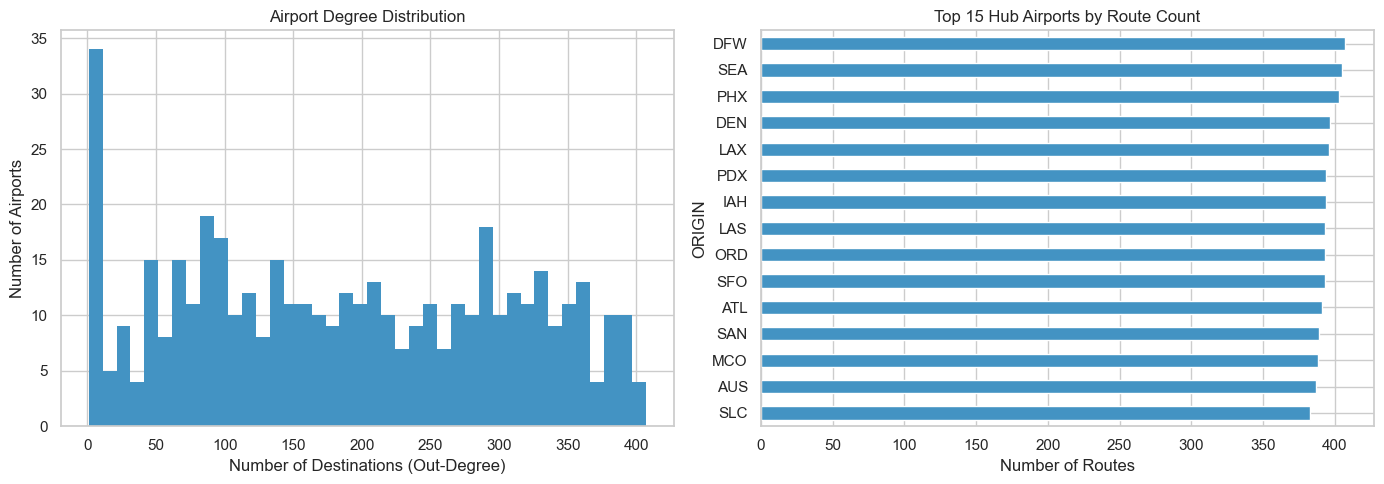

In [5]:
n_airports = df['ORIGIN'].nunique()
n_routes = df.groupby(['ORIGIN', 'DEST']).ngroups
print(f"Nodes (airports):       {n_airports:,}")
print(f"Edges (unique routes):  {n_routes:,}")
print(f"Avg routes per airport: {n_routes / n_airports:.1f}")

degree = df.groupby('ORIGIN')['DEST'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(degree.values, bins=40, color=BLUE, edgecolor='none')
axes[0].set_xlabel('Number of Destinations (Out-Degree)')
axes[0].set_ylabel('Number of Airports')
axes[0].set_title('Airport Degree Distribution')

degree.head(15).plot(kind='barh', ax=axes[1], color=BLUE)
axes[1].invert_yaxis()
axes[1].set_xlabel('Number of Routes')
axes[1].set_title('Top 15 Hub Airports by Route Count')

plt.tight_layout()
plt.show()

## 4. Geographic Analysis

Latitude/longitude are node features in the GNN. Distance correlates with fare but is far from a perfect predictor — especially for hub airports where competition suppresses prices.

In [6]:
import hvplot.pandas
import holoviews as hv
hv.extension('bokeh')

# --- Distance vs Fare: hvplot + datashader (interactive, 3M sample points) ---
fare_cap = df_sample['MARKET_FARE'].quantile(0.99)
df_ds = df_sample[df_sample['MARKET_FARE'] <= fare_cap].copy()
df_ds['QUARTER'] = df_ds['QUARTER'].astype(str).astype('category')

plot = df_ds.hvplot.scatter(
    'MARKET_DISTANCE', 'MARKET_FARE',
    by='QUARTER',
    datashade=True,
    dynspread=True,
    color_key=Q_COLORS,
    width=700, height=450,
    xlabel='Market Distance (miles)',
    ylabel='Market Fare ($)',
    title='Distance vs Fare — 3M routes (datashader, colored by Quarter)'
)
plot

BokehModel(combine_events=True, render_bundle={'docs_json': {'8a6a163c-78d1-414e-94b3-b7adb89d76cb': {'version…

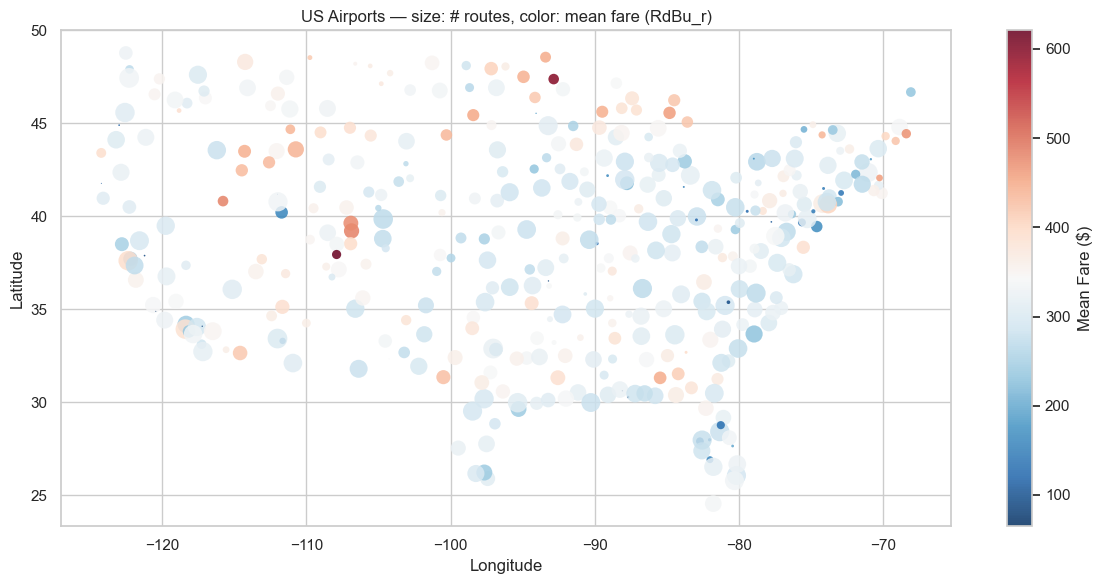

In [7]:
# --- US Airport Map: size = degree, color = mean fare (RdBu_r) ---
airport_stats = (
    df.groupby('ORIGIN')
    .agg(degree=('DEST', 'nunique'),
         mean_fare=('MARKET_FARE', 'mean'),
         lat=('ORIGIN_LAT', 'first'),
         lon=('ORIGIN_LON', 'first'))
    .reset_index()
)
us = airport_stats[airport_stats['lon'].between(-130, -65) & airport_stats['lat'].between(24, 50)]

fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(us['lon'], us['lat'],
                s=us['degree'] * 0.5,
                c=us['mean_fare'], cmap='RdBu_r',
                alpha=0.85, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Mean Fare ($)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('US Airports — size: # routes, color: mean fare (RdBu_r)')
plt.tight_layout()
plt.show()

## 5. Seasonal Patterns

Fares vary by quarter — summer and holiday periods show different pricing. Quarter is included as a cyclic edge feature in the GNN.

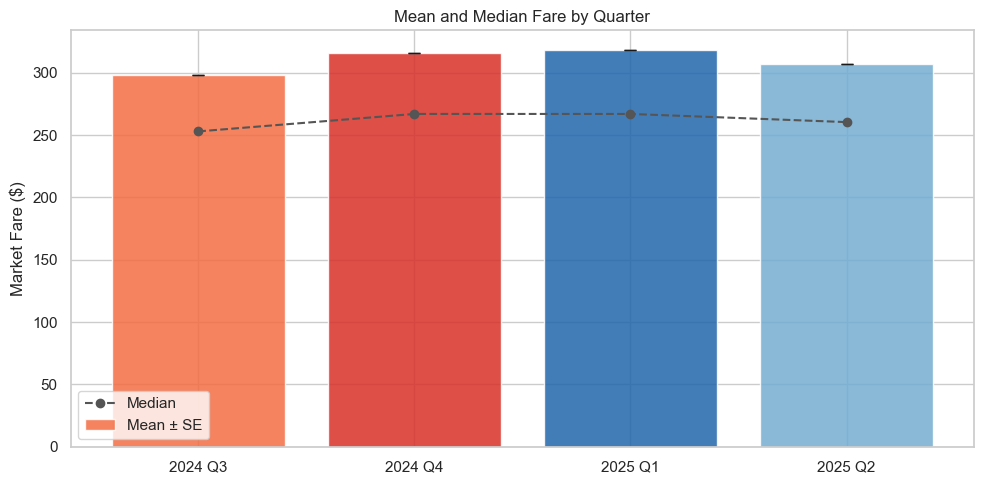

  label       mean  median        std
2024 Q3 298.050184  253.00 212.826681
2024 Q4 315.604378  267.00 226.736017
2025 Q1 318.002466  267.00 236.486737
2025 Q2 307.114030  260.46 223.159585


In [8]:
quarter_stats = (
    df.groupby(['YEAR', 'QUARTER'])['MARKET_FARE']
    .agg(mean='mean', median='median', std='std', n='count')
    .reset_index()
)
quarter_stats['label'] = quarter_stats['YEAR'].astype(str) + ' Q' + quarter_stats['QUARTER'].astype(str)

# Map each row to its RdBu_r quarter color
bar_colors = [Q_COLORS[str(q)] for q in quarter_stats['QUARTER']]

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(quarter_stats))
ax.bar(x, quarter_stats['mean'], yerr=quarter_stats['std'] / np.sqrt(quarter_stats['n']),
       color=bar_colors, alpha=0.85, capsize=4, label='Mean ± SE')
ax.plot(x, quarter_stats['median'], 'o--', color='#555555', label='Median')
ax.set_xticks(list(x))
ax.set_xticklabels(quarter_stats['label'])
ax.set_ylabel('Market Fare ($)')
ax.set_title('Mean and Median Fare by Quarter')
ax.legend()
plt.tight_layout()
plt.show()

print(quarter_stats[['label', 'mean', 'median', 'std']].to_string(index=False))

## 6. Carrier Effects

Different carriers price routes differently. Carrier is encoded as an edge feature in the GNN.

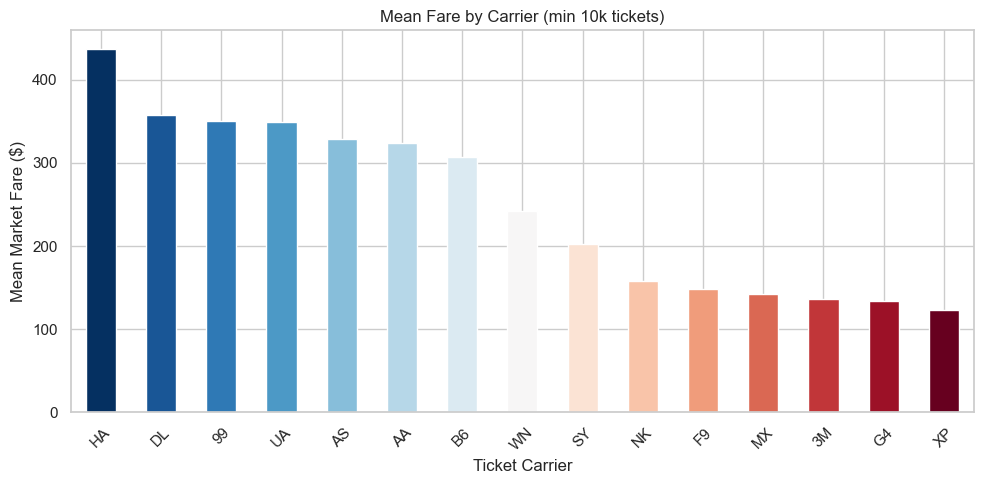

                 mean_fare  n_tickets
TICKET_CARRIER                       
HA              437.487184     177229
DL              357.597055    5501149
99              350.570222     404666
UA              349.557467    4849321
AS              329.294091    1269243
AA              324.001590    6445912
B6              307.045500     561665
WN              242.503102    5856040
SY              202.083114      38617
NK              157.787630     476887
F9              148.237813     445084
MX              142.947469     132424
3M              136.634240      11157
G4              134.010071     236723
XP              123.349807      47226


In [9]:
carrier_fare = (
    df.groupby('TICKET_CARRIER')['MARKET_FARE']
    .agg(mean_fare='mean', n_tickets='count')
    .query('n_tickets >= 10000')
    .sort_values('mean_fare', ascending=False)
    .head(15)
)

# Color bars by rank using RdBu_r (highest fare = red, lowest = blue)
n = len(carrier_fare)
cmap = plt.cm.RdBu_r
colors = [cmap(i / (n - 1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(10, 5))
carrier_fare['mean_fare'].plot(kind='bar', ax=ax, color=colors)
ax.set_xlabel('Ticket Carrier')
ax.set_ylabel('Mean Market Fare ($)')
ax.set_title('Mean Fare by Carrier (min 10k tickets)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(carrier_fare.to_string())

## 7. Feature Correlations

Distance and mileage are the strongest numeric predictors of fare, but the correlation is far from perfect — motivating graph neighborhood context (e.g., hub vs. regional airport) as additional signal.

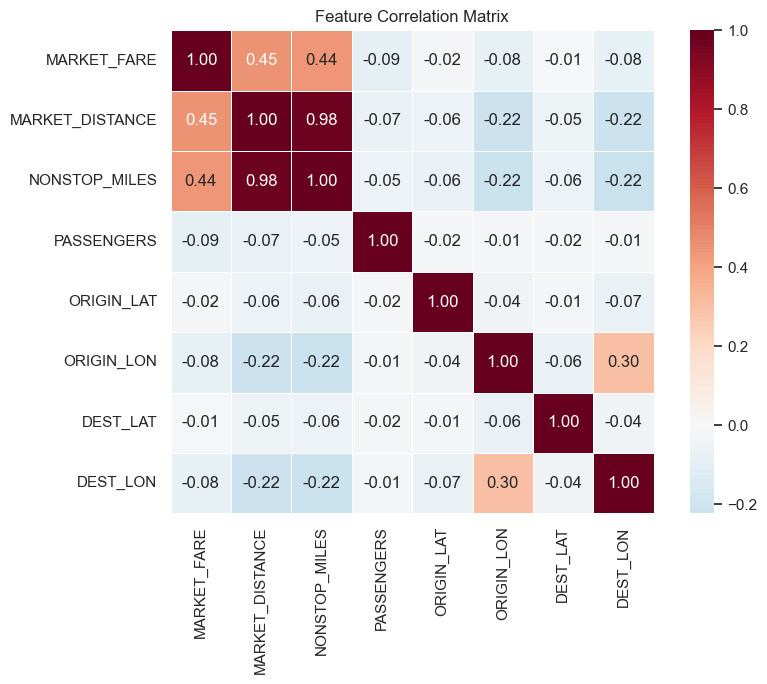

In [10]:
num_cols = ['MARKET_FARE', 'MARKET_DISTANCE', 'NONSTOP_MILES',
            'PASSENGERS', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON']

corr = df_sample[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 8. Route-Level Fare Variance

The same route (ORIGIN → DEST) has significant fare variance across quarters and carriers. This motivates using temporal and graph-contextual features rather than simple distance-based regression.

Routes with ≥20 observations: 40,781

Within-route fare std dev:
count    40781.000000
mean       174.172947
std         96.338019
min          9.047297
25%        125.263186
50%        152.278905
75%        193.637047
max       3699.303809


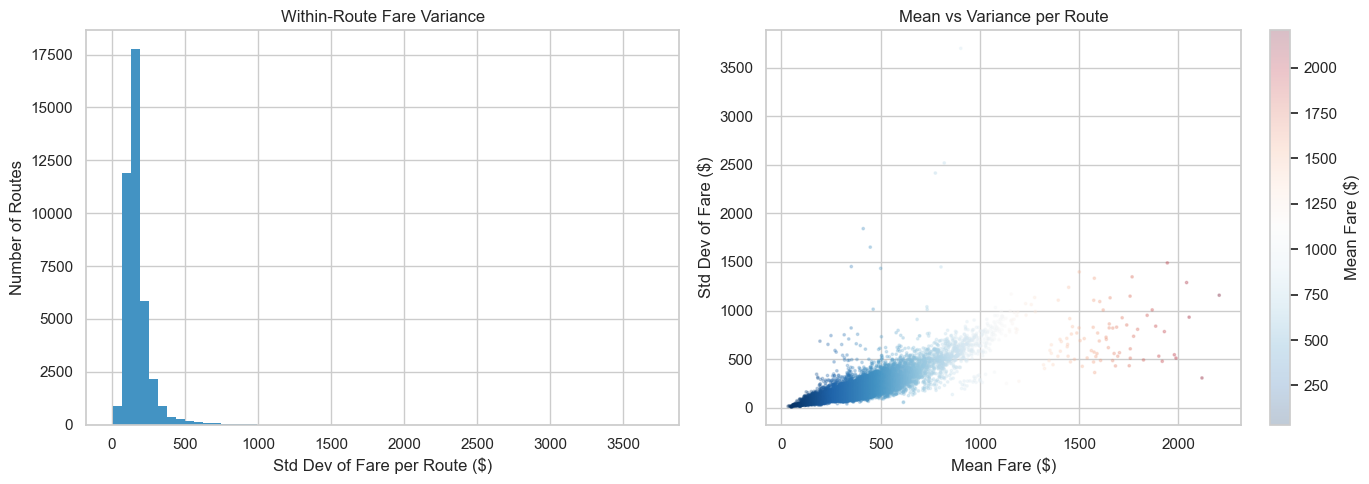

In [11]:
route_stats = (
    df.groupby(['ORIGIN', 'DEST'])['MARKET_FARE']
    .agg(mean_fare='mean', std_fare='std', n_obs='count')
    .query('n_obs >= 20')
    .reset_index()
)

print(f"Routes with ≥20 observations: {len(route_stats):,}")
print(f"\nWithin-route fare std dev:")
print(route_stats['std_fare'].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(route_stats['std_fare'].dropna(), bins=60, color=BLUE, edgecolor='none')
axes[0].set_xlabel('Std Dev of Fare per Route ($)')
axes[0].set_ylabel('Number of Routes')
axes[0].set_title('Within-Route Fare Variance')

sc = axes[1].scatter(route_stats['mean_fare'], route_stats['std_fare'],
                     c=route_stats['mean_fare'], cmap='RdBu_r',
                     alpha=0.25, s=3)
plt.colorbar(sc, ax=axes[1], label='Mean Fare ($)')
axes[1].set_xlabel('Mean Fare ($)')
axes[1].set_ylabel('Std Dev of Fare ($)')
axes[1].set_title('Mean vs Variance per Route')

plt.tight_layout()
plt.show()